# Overall Cross-Benchmark Leaderboards

This notebook builds version leaderboards aggregated across benchmarks from `v10+` results.

It supports:
- configurable **metric weights**
- configurable **benchmark weights** (default equal benchmark weighting)
- two ranking modes:
  - Primary metrics
  - Primary + Diversity


In [1]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/overall
_repo_root = Path.cwd().parents[2]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    build_overall_version_leaderboard,
    discover_benchmark_names,
    plot_leaderboard_scores,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)


In [2]:
# Configuration
benchmarks = discover_benchmark_names(base_path)
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

# Default benchmark weighting is equal.
# Customize this dict to emphasize/de-emphasize specific benchmarks.
benchmark_weights = {benchmark: 1.0 for benchmark in benchmarks}

print("Base path:", base_path)
print("Benchmarks discovered:", benchmarks)
print("Primary metric weights:", primary_metric_weights)
print("Primary + Diversity metric weights:", primary_plus_diversity_metric_weights)
print("Benchmark weights:", benchmark_weights)


Base path: /Users/franciscolozano/Documents/Github/sage-nrp-image-search/benchmarking/benchmarks
Benchmarks discovered: ['Cloudbench', 'Commonobjectsbench', 'Firebench', 'INQUIRE', 'Sagebench']
Primary metric weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity metric weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}
Benchmark weights: {'Cloudbench': 1.0, 'Commonobjectsbench': 1.0, 'Firebench': 1.0, 'INQUIRE': 1.0, 'Sagebench': 1.0}


## Overall Primary Leaderboard

Composite score uses `MRR` and `Success@25`.


,system_version,benchmark_count,MRR,Success@25,composite_score,rank_overall
0,v10,5,0.473390,0.573181,0.523285,1
1,v11,5,0.431017,0.609053,0.520035,2


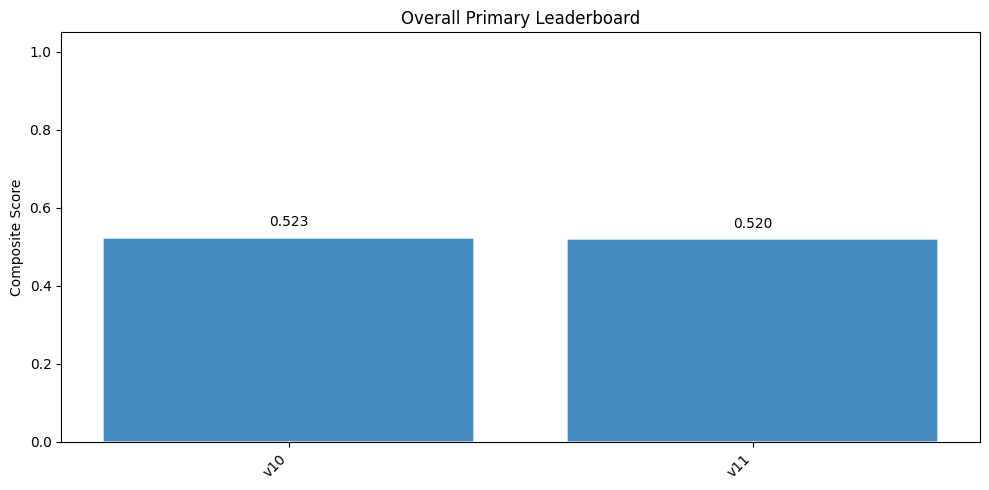

In [3]:
overall_primary_df = build_overall_version_leaderboard(
    base_path=base_path,
    benchmarks=benchmarks,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    benchmark_weights=benchmark_weights,
)

display(overall_primary_df)
plot_leaderboard_scores(overall_primary_df, label_column="system_version", title="Overall Primary Leaderboard")


## Overall Primary + Diversity Leaderboard

Composite score adds `Diversity@25`.


,system_version,benchmark_count,MRR,Success@25,Diversity@25,composite_score,rank_overall
0,v10,5,0.473390,0.573181,0.244298,0.430290,1
1,v11,5,0.431017,0.609053,0.249047,0.429706,2


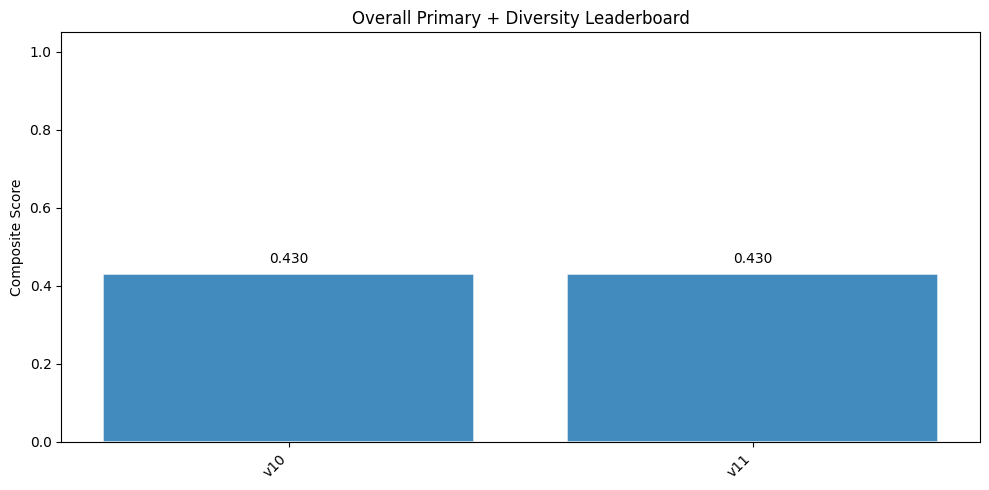

In [4]:
overall_primary_plus_diversity_df = build_overall_version_leaderboard(
    base_path=base_path,
    benchmarks=benchmarks,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    benchmark_weights=benchmark_weights,
)

display(overall_primary_plus_diversity_df)
plot_leaderboard_scores(
    overall_primary_plus_diversity_df,
    label_column="system_version",
    title="Overall Primary + Diversity Leaderboard",
)
